# Market Basket Analysis with Apriori

## Business Objective

This project explores product purchasing patterns in transactional retail data using association rule mining.

The objective is to identify products that are frequently purchased together, evaluate the strength of these relationships using support, confidence and lift, and translate the resulting rules into practical retail insights.

The analysis focuses on distinguishing genuinely meaningful product associations from combinations that occur frequently only because individual products are popular.

In [1]:
!pip install -q ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

online_retail = fetch_ucirepo(id=352)
df = online_retail.data.original.copy()

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nCancelled invoice rows:", df["InvoiceNo"].astype(str).str.startswith("C").sum())
print("Rows with Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("Rows with UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())

print("\nUnique invoices:", df["InvoiceNo"].nunique())
print("Unique products:", df["StockCode"].nunique())
print("Countries:", df["Country"].nunique())

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate rows: 5268

Cancelled invoice rows: 9288
Rows with Quantity <= 0: 10624
Rows with UnitPrice <= 0: 2517

Unique invoices: 25900
Unique products: 4070
Countries: 38


In [4]:
# Clean transactional data for market basket analysis
df_clean = df.drop_duplicates().copy()

df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
    & (df_clean["Quantity"] > 0)
    & (df_clean["UnitPrice"] > 0)
].copy()

print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

print("\nRemaining invoices:", df_clean["InvoiceNo"].nunique())
print("Remaining products:", df_clean["StockCode"].nunique())
print("Remaining countries:", df_clean["Country"].nunique())
print("Missing descriptions after cleaning:", df_clean["Description"].isnull().sum())

Original rows: 541909
Clean rows: 524878
Rows removed: 17031

Remaining invoices: 19960
Remaining products: 3922
Remaining countries: 38
Missing descriptions after cleaning: 0


In [5]:
country_summary = (
    df_clean
    .groupby("Country")
    .agg(
        Rows=("InvoiceNo", "size"),
        Invoices=("InvoiceNo", "nunique"),
        Products=("StockCode", "nunique")
    )
    .sort_values("Invoices", ascending=False)
)

country_summary["InvoiceSharePct"] = (
    country_summary["Invoices"]
    / country_summary["Invoices"].sum()
    * 100
)

country_summary.head(10).round(2)

,Rows,Invoices,Products,InvoiceSharePct
Country,,,,
United Kingdom,479985,18019,3916,90.28
Germany,9025,457,1664,2.29
France,8392,392,1542,1.96
EIRE,7879,288,1968,1.44
Belgium,2031,98,777,0.49
Netherlands,2359,94,782,0.47
Spain,2479,90,1091,0.45
Portugal,1492,58,706,0.29
Australia,1181,57,599,0.29


## Market Selection

The United Kingdom accounts for 90.28% of all cleaned invoices, with 18,019 transactions and 3,916 distinct products.

Because it overwhelmingly dominates the dataset, the Market Basket Analysis will focus on UK transactions.

Restricting the analysis to a single major market also avoids mixing potentially different purchasing behaviours across countries and provides a large, coherent transaction base for association rule mining.

In [6]:
# Focus the analysis on United Kingdom transactions
uk_data = df_clean[
    df_clean["Country"] == "United Kingdom"
].copy()

print("UK rows:", len(uk_data))
print("UK invoices:", uk_data["InvoiceNo"].nunique())
print("UK products:", uk_data["StockCode"].nunique())

UK rows: 479985
UK invoices: 18019
UK products: 3916


In [7]:
# Analyse basket sizes
basket_sizes = (
    uk_data
    .groupby("InvoiceNo")["StockCode"]
    .nunique()
)

print("Number of baskets:", len(basket_sizes))
print("Average unique products per basket:", round(basket_sizes.mean(), 2))
print("Median unique products per basket:", round(basket_sizes.median(), 2))
print("Maximum unique products in a basket:", basket_sizes.max())
print("Single-product baskets:", (basket_sizes == 1).sum())
print(
    "Single-product baskets (%):",
    round((basket_sizes == 1).mean() * 100, 2)
)

print("\nBasket size percentiles:")
print(basket_sizes.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

Number of baskets: 18019
Average unique products per basket: 26.35
Median unique products per basket: 15.0
Maximum unique products in a basket: 1110
Single-product baskets: 1497
Single-product baskets (%): 8.31

Basket size percentiles:
0.25      6.00
0.50     15.00
0.75     29.00
0.90     52.00
0.95     77.00
0.99    229.82
Name: StockCode, dtype: float64


## Basket Structure

The UK dataset contains 18,019 valid transaction baskets.

Basket sizes vary substantially:

- Average unique products per basket: 26.35
- Median unique products per basket: 15
- 75% of baskets contain 29 products or fewer
- 8.31% of baskets contain only one unique product
- The largest basket contains 1,110 unique products

Single-product baskets are retained because they represent genuine transactions. Removing them would alter the transaction population and could artificially increase association metrics by excluding purchases in which products were bought independently.

In [8]:
# Identify the most frequently purchased products
product_frequency = (
    uk_data
    .groupby(["StockCode", "Description"])
    .agg(
        Invoices=("InvoiceNo", "nunique"),
        TotalQuantity=("Quantity", "sum")
    )
    .sort_values("Invoices", ascending=False)
)

product_frequency.head(20)

,,Invoices,TotalQuantity
StockCode,Description,,
85123A,WHITE HANGING HEART T-LIGHT HOLDER,2095,35430
85099B,JUMBO BAG RED RETROSPOT,1935,44161
22423,REGENCY CAKESTAND 3 TIER,1685,11044
47566,PARTY BUNTING,1593,16961
20725,LUNCH BAG RED RETROSPOT,1392,14990
84879,ASSORTED COLOUR BIRD ORNAMENT,1371,33636
22720,SET OF 3 CAKE TINS PANTRY DESIGN,1241,5695
22457,NATURAL SLATE HEART CHALKBOARD,1219,8747
20727,LUNCH BAG BLACK SKULL.,1216,10800


In [9]:
# Inspect StockCodes that do not follow the usual product-code pattern
stockcode_text = uk_data["StockCode"].astype(str)

unusual_codes = uk_data[
    ~stockcode_text.str.match(r"^\d{5}[A-Z]*$")
]

unusual_code_summary = (
    unusual_codes
    .groupby(["StockCode", "Description"])
    .agg(
        Rows=("InvoiceNo", "size"),
        Invoices=("InvoiceNo", "nunique"),
        TotalQuantity=("Quantity", "sum")
    )
    .sort_values("Invoices", ascending=False)
)

print("Unusual StockCodes:", unusual_codes["StockCode"].nunique())
print("Rows affected:", len(unusual_codes))

unusual_code_summary.head(30)

Unusual StockCodes: 133
Rows affected: 3089


,,Rows,Invoices,TotalQuantity
StockCode,Description,,,
DOT,DOTCOM POSTAGE,706,706,706
M,Manual,274,256,6939
47566b,TEA TIME PARTY BUNTING,102,102,199
15056n,EDWARDIAN PARASOL NATURAL,84,84,127
72349b,SET/6 PURPLE BUTTERFLY T-LIGHTS,82,82,159
84509a,SET OF 4 ENGLISH ROSE PLACEMATS,68,68,104
85123a,WHITE HANGING HEART T-LIGHT HOLDER,67,67,292
84970s,HANGING HEART ZINC T-LIGHT HOLDER,66,66,238
84997d,CHILDRENS CUTLERY POLKADOT PINK,67,65,285


In [10]:
# Inspect codes that do not begin with a numeric product identifier
non_product_candidates = uk_data[
    ~uk_data["StockCode"].astype(str).str.match(r"^\d")
]

non_product_summary = (
    non_product_candidates
    .groupby(["StockCode", "Description"])
    .agg(
        Rows=("InvoiceNo", "size"),
        Invoices=("InvoiceNo", "nunique"),
        TotalQuantity=("Quantity", "sum")
    )
    .sort_values("Invoices", ascending=False)
)

print("Candidate non-product StockCodes:",
      non_product_candidates["StockCode"].nunique())

non_product_summary

Candidate non-product StockCodes: 22


,,Rows,Invoices,TotalQuantity
StockCode,Description,,,
DOT,DOTCOM POSTAGE,706,706,706
M,Manual,274,256,6939
POST,POSTAGE,52,52,66
C2,CARRIAGE,30,30,30
DCGSSGIRL,GIRLS PARTY BAG,13,13,47
BANK CHARGES,Bank Charges,12,11,12
DCGSSBOY,BOYS PARTY BAG,11,11,47
gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,9,9,10
gift_0001_10,Dotcomgiftshop Gift Voucher £10.00,8,8,9


## Product Scope

Market Basket Analysis should focus on relationships between merchandise rather than administrative or service-related invoice lines.

A review of non-standard stock codes identified a small number of entries representing postage, carriage, manual adjustments, bank charges, marketplace fees, bad-debt adjustments, samples and gift vouchers.

These entries are excluded from association-rule modelling because they do not represent ordinary retail products and could create misleading relationships between merchandise and transactional charges.

Non-standard codes that clearly correspond to physical products are retained.

In [11]:
# Exclude administrative and non-merchandise stock codes
excluded_codes = [
    "DOT",
    "POST",
    "C2",
    "M",
    "m",
    "BANK CHARGES",
    "AMAZONFEE",
    "B",
    "S"
]

product_data = uk_data[
    ~uk_data["StockCode"].astype(str).isin(excluded_codes)
    & ~uk_data["StockCode"].astype(str).str.startswith("gift_")
].copy()

print("Rows before product filtering:", len(uk_data))
print("Rows after product filtering:", len(product_data))
print("Rows removed:", len(uk_data) - len(product_data))

print("\nInvoices before filtering:", uk_data["InvoiceNo"].nunique())
print("Invoices after filtering:", product_data["InvoiceNo"].nunique())

print("Products after filtering:", product_data["StockCode"].nunique())

Rows before product filtering: 479985
Rows after product filtering: 478874
Rows removed: 1111

Invoices before filtering: 18019
Invoices after filtering: 17901
Products after filtering: 3902


## Transaction Filtering Summary

After restricting the analysis to UK transactions, administrative and non-merchandise invoice lines were removed from the association-rule dataset.

The filtering removed 1,111 rows and reduced the number of usable invoices from 18,019 to 17,901.

The final transaction dataset contains 478,874 product lines and 3,902 distinct merchandise items.

Physical products with non-standard stock-code formats were retained. Only entries identified as transactional charges, adjustments, samples or gift vouchers were excluded.

In [12]:
!pip install -q mlxtend

In [13]:
from mlxtend.preprocessing import TransactionEncoder

# Build product baskets by invoice
transactions = (
    product_data
    .groupby("InvoiceNo")["StockCode"]
    .apply(lambda x: list(pd.unique(x.astype(str))))
    .tolist()
)

# Encode baskets as a boolean transaction matrix
te = TransactionEncoder()

basket_array = te.fit(transactions).transform(transactions)

basket_df = pd.DataFrame(
    basket_array,
    columns=te.columns_,
    dtype=bool
)

print("Number of baskets:", basket_df.shape[0])
print("Number of products:", basket_df.shape[1])
print("Basket matrix shape:", basket_df.shape)
print("Basket density:", round(basket_df.to_numpy().mean(), 4))

Number of baskets: 17901
Number of products: 3902
Basket matrix shape: (17901, 3902)
Basket density: 0.0068


## Basket Encoding

The cleaned UK transactions were transformed into a binary basket matrix in which each row represents an invoice and each column represents a product.

A value indicates whether a product was present in a given transaction, regardless of the quantity purchased.

The resulting matrix contains:

- 17,901 transaction baskets
- 3,902 distinct products
- Matrix density: 0.68%

Because the matrix is highly sparse, a sparse representation is used to reduce unnecessary memory consumption while preserving the complete transaction structure required for association rule mining.

In [14]:
# Calculate individual product support
product_support = basket_df.mean(axis=0).sort_values(ascending=False)

support_thresholds = [0.005, 0.01, 0.02, 0.03, 0.05]

print("Products meeting each minimum support threshold:\n")

for threshold in support_thresholds:
    count = (product_support >= threshold).sum()
    invoices = round(threshold * len(basket_df))

    print(
        f"Support >= {threshold:.3f} "
        f"(~{invoices} invoices): {count} products"
    )

print("\nTop 10 product support values:")
print(product_support.head(10).round(4))

Products meeting each minimum support threshold:

Support >= 0.005 (~90 invoices): 1561 products
Support >= 0.010 (~179 invoices): 825 products
Support >= 0.020 (~358 invoices): 301 products
Support >= 0.030 (~537 invoices): 133 products
Support >= 0.050 (~895 invoices): 37 products

Top 10 product support values:
85123A    0.1175
85099B    0.1081
22423     0.0941
47566     0.0890
20725     0.0778
84879     0.0766
22197     0.0724
22720     0.0693
22457     0.0681
20727     0.0679
dtype: float64


## Minimum Support Selection

Individual product frequency was evaluated before running Apriori in order to select a meaningful minimum support threshold.

At a 2% support threshold, 301 products remain eligible for frequent-pattern analysis. This corresponds to products appearing in approximately 358 or more of the 17,901 transaction baskets.

A 1% threshold would retain 825 products and could generate a substantially larger and noisier search space, while thresholds of 3% or higher may exclude potentially useful product relationships.

The initial Apriori analysis therefore uses a minimum support of 2%. The resulting number and quality of frequent itemsets will be reviewed before generating association rules.

In [15]:
from mlxtend.frequent_patterns import apriori

# Generate frequent itemsets
frequent_itemsets = apriori(
    basket_df,
    min_support=0.02,
    use_colnames=True,
    max_len=3,
    low_memory=True
)

frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

print("Total frequent itemsets:", len(frequent_itemsets))

print("\nItemsets by length:")
print(frequent_itemsets["length"].value_counts().sort_index())

print("\nTop 10 frequent itemsets:")
print(
    frequent_itemsets
    .sort_values("support", ascending=False)
    .head(10)
)

Total frequent itemsets: 412

Itemsets by length:
length
1    301
2    106
3      5
Name: count, dtype: int64

Top 10 frequent itemsets:
      support  itemsets  length
298  0.117535  (85123A)       1
295  0.108095  (85099B)       1
124  0.094129   (22423)       1
254  0.088989   (47566)       1
12   0.077761   (20725)       1
284  0.076588   (84879)       1
103  0.072398   (22197)       1
177  0.069326   (22720)       1
129  0.068097   (22457)       1
14   0.067929   (20727)       1


In [16]:
from mlxtend.frequent_patterns import association_rules

# Generate all association rules from the frequent itemsets
all_rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.0
)

print("Total association rules:", len(all_rules))

print("\nRules meeting different confidence thresholds:")

for threshold in [0.20, 0.30, 0.40, 0.50]:
    count = (
        (all_rules["confidence"] >= threshold)
        & (all_rules["lift"] > 1)
    ).sum()

    print(
        f"Confidence >= {threshold:.0%} and Lift > 1: "
        f"{count} rules"
    )

Total association rules: 242

Rules meeting different confidence thresholds:
Confidence >= 20% and Lift > 1: 231 rules
Confidence >= 30% and Lift > 1: 203 rules
Confidence >= 40% and Lift > 1: 150 rules
Confidence >= 50% and Lift > 1: 77 rules


In [17]:
# Examine lift strength among rules with at least 40% confidence
high_conf_rules = all_rules[
    all_rules["confidence"] >= 0.40
].copy()

print("Rules with Confidence >= 40%:", len(high_conf_rules))

print("\nRules meeting different lift thresholds:")

for threshold in [1.0, 1.5, 2.0, 3.0]:
    count = (high_conf_rules["lift"] >= threshold).sum()

    print(
        f"Lift >= {threshold:.1f}: "
        f"{count} rules"
    )

print("\nLift distribution:")
print(
    high_conf_rules["lift"]
    .describe()
    .round(2)
)

Rules with Confidence >= 40%: 150

Rules meeting different lift thresholds:
Lift >= 1.0: 150 rules
Lift >= 1.5: 150 rules
Lift >= 2.0: 150 rules
Lift >= 3.0: 150 rules

Lift distribution:
count    150.00
mean       9.46
std        4.06
min        3.94
25%        6.86
50%        7.84
75%       12.66
max       27.02
Name: lift, dtype: float64


In [18]:
# Check description consistency for each product code
description_counts = (
    product_data
    .groupby("StockCode")["Description"]
    .nunique()
)

print("Products with one unique description:",
      (description_counts == 1).sum())

print("Products with multiple descriptions:",
      (description_counts > 1).sum())

print("Maximum descriptions for a single StockCode:",
      description_counts.max())

Products with one unique description: 3692
Products with multiple descriptions: 210
Maximum descriptions for a single StockCode: 4


In [19]:
# Create a canonical product description for each StockCode
product_description = (
    product_data
    .groupby(["StockCode", "Description"])
    .size()
    .reset_index(name="Count")
    .sort_values(
        ["StockCode", "Count"],
        ascending=[True, False]
    )
    .drop_duplicates("StockCode")
    .set_index("StockCode")["Description"]
)

print("Product descriptions mapped:", len(product_description))

print("\nExamples:")
print(product_description.head(10))

Product descriptions mapped: 3902

Examples:
StockCode
10002      INFLATABLE POLITICAL GLOBE 
10080         GROOVY CACTUS INFLATABLE
10120                     DOGGY RUBBER
10123C           HEARTS WRAPPING TAPE 
10124A     SPOTS ON RED BOOKCOVER TAPE
10124G        ARMY CAMO BOOKCOVER TAPE
10125          MINI FUNKY DESIGN TAPES
10133     COLOURING PENCILS BROWN TUBE
10135     COLOURING PENCILS BROWN TUBE
11001      ASSTD DESIGN RACING CAR PEN
Name: Description, dtype: object


In [20]:
# Create a readable version of the selected association rules
description_map = {
    str(code): description
    for code, description in product_description.items()
}

def itemset_to_names(itemset):
    return " + ".join(
        description_map.get(str(code), str(code))
        for code in sorted(itemset)
    )

selected_rules = high_conf_rules.copy()

selected_rules["Antecedent"] = (
    selected_rules["antecedents"]
    .apply(itemset_to_names)
)

selected_rules["Consequent"] = (
    selected_rules["consequents"]
    .apply(itemset_to_names)
)

readable_rules = (
    selected_rules[
        ["Antecedent", "Consequent", "support", "confidence", "lift"]
    ]
    .sort_values(
        ["lift", "confidence"],
        ascending=False
    )
)

print("Selected rules:", len(readable_rules))

readable_rules.head(20).round(3)

Selected rules: 150


,Antecedent,Consequent,support,confidence,lift
157,WOODEN STAR CHRISTMAS SCANDINAVIAN,WOODEN HEART CHRISTMAS SCANDINAVIAN,0.021,0.768,27.019
156,WOODEN HEART CHRISTMAS SCANDINAVIAN,WOODEN STAR CHRISTMAS SCANDINAVIAN,0.021,0.723,27.019
237,GREEN REGENCY TEACUP AND SAUCER + ROSES REGENC...,PINK REGENCY TEACUP AND SAUCER,0.027,0.703,17.923
240,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER + ROSES REGENC...,0.027,0.701,17.923
236,PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY...,GREEN REGENCY TEACUP AND SAUCER,0.027,0.903,17.339
241,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY...,0.027,0.528,17.339
239,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY...,0.027,0.515,15.994
238,GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY...,ROSES REGENCY TEACUP AND SAUCER,0.027,0.854,15.994
162,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.032,0.821,15.760
163,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.032,0.618,15.760


In [21]:
# Separate simple product-to-product rules
simple_rules = selected_rules[
    (selected_rules["antecedents"].apply(len) == 1)
    & (selected_rules["consequents"].apply(len) == 1)
].copy()

simple_rules["Antecedent"] = (
    simple_rules["antecedents"]
    .apply(itemset_to_names)
)

simple_rules["Consequent"] = (
    simple_rules["consequents"]
    .apply(itemset_to_names)
)

simple_rules_readable = (
    simple_rules[
        ["Antecedent", "Consequent", "support", "confidence", "lift"]
    ]
    .sort_values(
        ["lift", "confidence"],
        ascending=False
    )
)

print("Simple product-to-product rules:", len(simple_rules_readable))

simple_rules_readable.head(20).round(3)

Simple product-to-product rules: 132


,Antecedent,Consequent,support,confidence,lift
157,WOODEN STAR CHRISTMAS SCANDINAVIAN,WOODEN HEART CHRISTMAS SCANDINAVIAN,0.021,0.768,27.019
156,WOODEN HEART CHRISTMAS SCANDINAVIAN,WOODEN STAR CHRISTMAS SCANDINAVIAN,0.021,0.723,27.019
162,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.032,0.821,15.760
163,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.032,0.618,15.760
159,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.024,0.609,15.563
158,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.024,0.608,15.563
10,STRAWBERRY CHARLOTTE BAG,WOODLAND CHARLOTTE BAG,0.021,0.556,14.608
11,WOODLAND CHARLOTTE BAG,STRAWBERRY CHARLOTTE BAG,0.021,0.549,14.608
167,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.030,0.776,14.537
166,ROSES REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.030,0.570,14.537


In [22]:
# Collapse reciprocal rules into unique product pairs
pair_rules = simple_rules_readable.copy()

pair_rules["PairKey"] = pair_rules.apply(
    lambda row: tuple(
        sorted([row["Antecedent"], row["Consequent"]])
    ),
    axis=1
)

unique_pairs = (
    pair_rules
    .sort_values(
        ["confidence", "lift"],
        ascending=False
    )
    .drop_duplicates("PairKey")
    .drop(columns="PairKey")
    .sort_values(
        ["lift", "confidence"],
        ascending=False
    )
)

print("Unique product pairs:", len(unique_pairs))

unique_pairs.head(20).round(3)

Unique product pairs: 92


,Antecedent,Consequent,support,confidence,lift
157,WOODEN STAR CHRISTMAS SCANDINAVIAN,WOODEN HEART CHRISTMAS SCANDINAVIAN,0.021,0.768,27.019
162,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.032,0.821,15.760
159,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.024,0.609,15.563
10,STRAWBERRY CHARLOTTE BAG,WOODLAND CHARLOTTE BAG,0.021,0.556,14.608
167,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.030,0.776,14.537
199,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.030,0.721,14.379
20,STRAWBERRY CHARLOTTE BAG,CHARLOTTE BAG PINK POLKADOT,0.020,0.538,14.307
26,CHARLOTTE BAG PINK POLKADOT,RED RETROSPOT CHARLOTTE BAG,0.027,0.712,14.109
165,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.039,0.751,14.064
177,JUMBO BAG PEARS,JUMBO BAG APPLES,0.021,0.679,13.731


In [23]:
# Examine the highest-volume product associations
high_volume_pairs = unique_pairs.copy()

high_volume_pairs["BasketCount"] = (
    high_volume_pairs["support"] * len(basket_df)
).round().astype(int)

high_volume_pairs = (
    high_volume_pairs[
        [
            "Antecedent",
            "Consequent",
            "BasketCount",
            "support",
            "confidence",
            "lift"
        ]
    ]
    .sort_values(
        ["support", "confidence"],
        ascending=False
    )
)

high_volume_pairs.head(20).round(3)

,Antecedent,Consequent,BasketCount,support,confidence,lift
137,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,785,0.044,0.677,6.266
165,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,700,0.039,0.751,14.064
109,JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT,698,0.039,0.618,5.714
141,JUMBO SHOPPER VINTAGE RED PAISLEY,JUMBO BAG RED RETROSPOT,657,0.037,0.580,5.365
33,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,607,0.034,0.499,6.419
39,LUNCH BAG SUKI DESIGN,LUNCH BAG RED RETROSPOT,602,0.034,0.502,6.451
162,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,576,0.032,0.821,15.760
207,JUMBO BAG BAROQUE BLACK WHITE,JUMBO BAG RED RETROSPOT,570,0.032,0.626,5.795
62,LUNCH BAG SUKI DESIGN,LUNCH BAG BLACK SKULL.,565,0.032,0.471,6.931
171,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,563,0.031,0.643,12.371


In [24]:
# Inspect all frequent three-product combinations
three_itemsets = frequent_itemsets[
    frequent_itemsets["length"] == 3
].copy()

three_itemsets["Products"] = (
    three_itemsets["itemsets"]
    .apply(itemset_to_names)
)

three_itemsets["BasketCount"] = (
    three_itemsets["support"] * len(basket_df)
).round().astype(int)

three_itemsets[
    ["Products", "BasketCount", "support"]
].sort_values(
    "support",
    ascending=False
).round(3)

,Products,BasketCount,support
411,GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY...,492,0.027
407,JUMBO STORAGE BAG SUKI + JUMBO BAG PINK POLKAD...,405,0.023
408,JUMBO STORAGE BAG SUKI + JUMBO SHOPPER VINTAGE...,384,0.021
409,JUMBO BAG PINK POLKADOT + JUMBO SHOPPER VINTAG...,366,0.020
410,REGENCY CAKESTAND 3 TIER + GREEN REGENCY TEACU...,359,0.020


In [25]:
# Display the complete three-product combinations
for _, row in three_itemsets.sort_values(
    "support",
    ascending=False
).iterrows():
    print(
        f"{row['Products']} "
        f"| Baskets: {row['BasketCount']} "
        f"| Support: {row['support']:.3f}"
    )

GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY TEACUP AND SAUCER  | Baskets: 492 | Support: 0.027
JUMBO STORAGE BAG SUKI + JUMBO BAG PINK POLKADOT + JUMBO BAG RED RETROSPOT | Baskets: 405 | Support: 0.023
JUMBO STORAGE BAG SUKI + JUMBO SHOPPER VINTAGE RED PAISLEY + JUMBO BAG RED RETROSPOT | Baskets: 384 | Support: 0.021
JUMBO BAG PINK POLKADOT + JUMBO SHOPPER VINTAGE RED PAISLEY + JUMBO BAG RED RETROSPOT | Baskets: 366 | Support: 0.020
REGENCY CAKESTAND 3 TIER + GREEN REGENCY TEACUP AND SAUCER + ROSES REGENCY TEACUP AND SAUCER  | Baskets: 359 | Support: 0.020


## Three-Product Bundle Opportunities

Five three-product combinations exceeded the 2% minimum support threshold.

The strongest bundle pattern was the Regency teacup collection:

- Green Regency Teacup and Saucer
- Pink Regency Teacup and Saucer
- Roses Regency Teacup and Saucer

This combination appeared in 492 baskets, representing 2.7% of UK transactions.

Several Jumbo Bag combinations also appeared frequently together, with three-product bundles occurring in approximately 366 to 405 baskets.

A further Regency combination linked the Regency Cakestand 3 Tier with Green and Roses Regency Teacups, appearing in 359 baskets.

These patterns suggest potential opportunities for coordinated product bundles, cross-selling recommendations and collection-based merchandising.

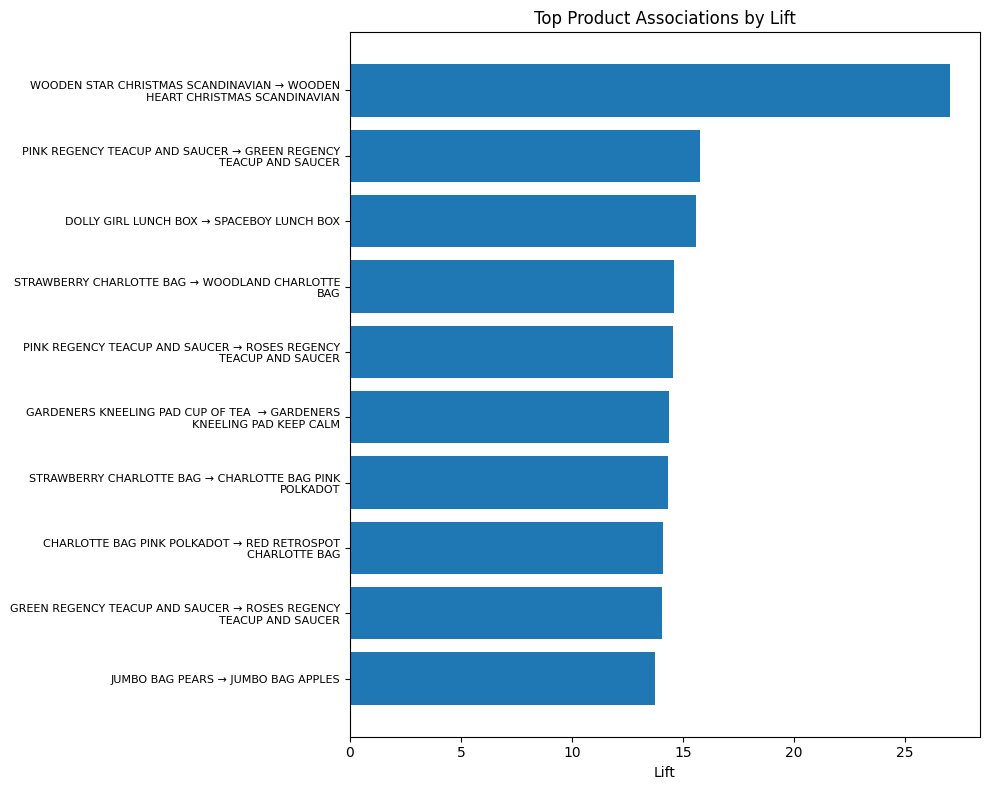

In [26]:
import matplotlib.pyplot as plt
import textwrap

# Select the strongest unique product associations by lift
top_pairs_plot = (
    unique_pairs
    .nlargest(10, "lift")
    .copy()
)

top_pairs_plot["Rule"] = (
    top_pairs_plot["Antecedent"]
    + " → "
    + top_pairs_plot["Consequent"]
)

top_pairs_plot["Rule"] = top_pairs_plot["Rule"].apply(
    lambda x: "\n".join(textwrap.wrap(x, width=48))
)

# Plot strongest associations
plt.figure(figsize=(10, 8))

plt.barh(
    range(len(top_pairs_plot)),
    top_pairs_plot["lift"]
)

plt.yticks(
    range(len(top_pairs_plot)),
    top_pairs_plot["Rule"],
    fontsize=8
)

plt.gca().invert_yaxis()

plt.title("Top Product Associations by Lift")
plt.xlabel("Lift")
plt.ylabel("")

plt.tight_layout()
plt.show()

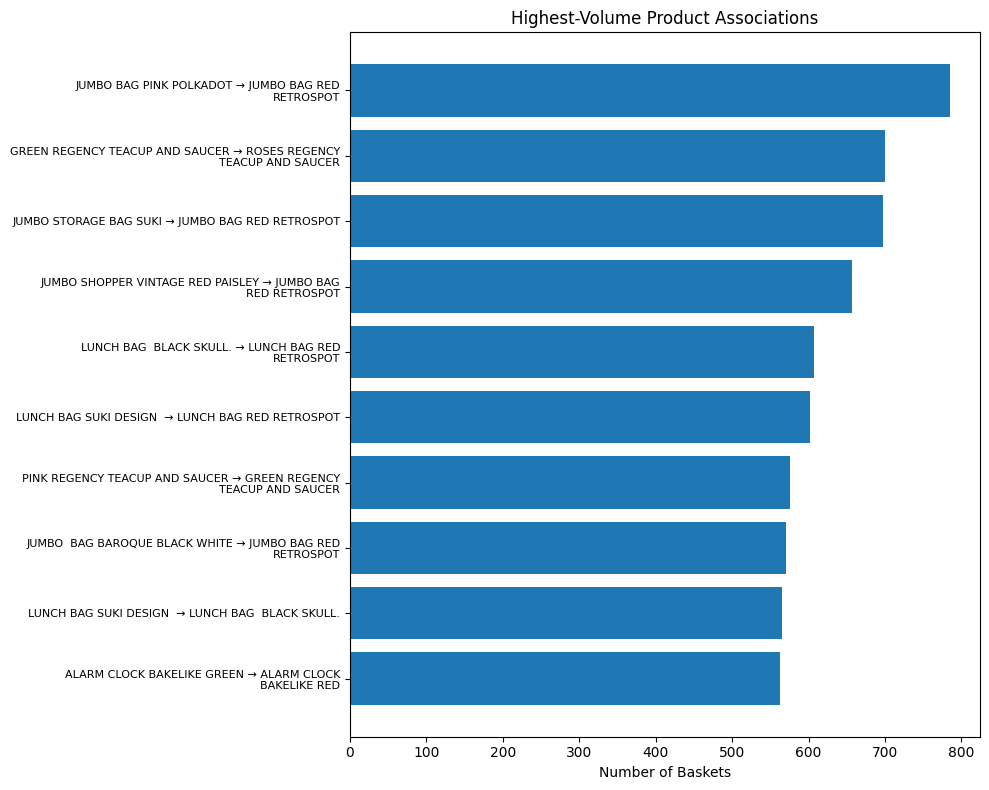

In [27]:
# Visualise the highest-volume product associations
top_volume_plot = (
    high_volume_pairs
    .head(10)
    .copy()
)

top_volume_plot["Rule"] = (
    top_volume_plot["Antecedent"]
    + " → "
    + top_volume_plot["Consequent"]
)

top_volume_plot["Rule"] = top_volume_plot["Rule"].apply(
    lambda x: "\n".join(textwrap.wrap(x, width=48))
)

plt.figure(figsize=(10, 8))

plt.barh(
    range(len(top_volume_plot)),
    top_volume_plot["BasketCount"]
)

plt.yticks(
    range(len(top_volume_plot)),
    top_volume_plot["Rule"],
    fontsize=8
)

plt.gca().invert_yaxis()

plt.title("Highest-Volume Product Associations")
plt.xlabel("Number of Baskets")
plt.ylabel("")

plt.tight_layout()
plt.show()

## Association Strength vs. Commercial Volume

The strongest association is not necessarily the one that occurs in the largest number of transactions.

Lift measures how much more frequently two products occur together than would be expected if their purchases were independent. High lift therefore highlights particularly strong relationships.

Support and basket count provide a different perspective by showing how widespread an association is across actual transactions.

For example, some product pairs achieve exceptionally high lift while appearing in a smaller proportion of baskets, whereas several Jumbo Bag and Regency combinations combine strong association metrics with substantial transaction volume.

For commercial decision-making, both perspectives are relevant:

- **High lift** can identify strong cross-selling or bundle relationships.
- **High basket volume** highlights opportunities with greater potential operational reach.
- Associations combining both characteristics are especially attractive for merchandising and recommendation strategies.

## Business Recommendations

The association rules reveal several product relationships that could support practical merchandising and cross-selling decisions.

### 1. Regency Collection Cross-Selling

Customers purchasing **Pink Regency Teacup and Saucer** also purchased **Green Regency Teacup and Saucer** with:

- Support: 3.2%
- Confidence: 82.1%
- Lift: 15.76

The Green and Roses Regency products also appeared together in 700 baskets, with 75.1% confidence and a lift of 14.06.

These results support product-page recommendations and coordinated merchandising across the Regency collection.

### 2. Regency Three-Product Bundle

The combination of:

- Green Regency Teacup and Saucer
- Pink Regency Teacup and Saucer
- Roses Regency Teacup and Saucer

appeared in 492 baskets, representing 2.7% of UK transactions.

This provides evidence for testing a coordinated three-product bundle or collection-based promotion.

### 3. Jumbo Bag Cross-Selling

**Jumbo Bag Pink Polkadot → Jumbo Bag Red Retrospot** was the highest-volume unique association identified:

- 785 baskets
- Support: 4.4%
- Confidence: 67.7%
- Lift: 6.27

Several other Jumbo Bag designs also appeared among the highest-volume rules, suggesting that customers frequently purchase multiple designs from the same product family.

This could support "frequently bought together" recommendations and multi-item promotions.

### 4. Seasonal Product Pairing

**Wooden Star Christmas Scandinavian → Wooden Heart Christmas Scandinavian** produced the strongest lift in the analysis:

- Support: 2.1%
- Confidence: 76.8%
- Lift: 27.02

Although the pair has lower transaction volume than some other associations, the exceptionally high lift suggests a strong seasonal relationship suitable for coordinated Christmas merchandising.

### 5. Complementary Garden Products

**Gardeners Kneeling Pad Cup of Tea → Gardeners Kneeling Pad Keep Calm** appeared in 541 baskets:

- Support: 3.0%
- Confidence: 72.1%
- Lift: 14.38

The strong relationship suggests another suitable candidate for paired recommendations or bundle testing.

These recommendations should be treated as evidence-based opportunities for experimentation rather than assumptions of causality. Association rules show products that occur together; they do not establish that purchasing one product causes the purchase of another.

In [28]:
# Analyse seasonality of the strongest Christmas association
product_data["InvoiceDate"] = pd.to_datetime(
    product_data["InvoiceDate"],
    format="%m/%d/%Y %H:%M"
)

star_code = product_description[
    product_description == "WOODEN STAR CHRISTMAS SCANDINAVIAN"
].index[0]

heart_code = product_description[
    product_description == "WOODEN HEART CHRISTMAS SCANDINAVIAN"
].index[0]

# Identify invoices containing both products
star_invoices = set(
    product_data.loc[
        product_data["StockCode"].astype(str) == str(star_code),
        "InvoiceNo"
    ]
)

heart_invoices = set(
    product_data.loc[
        product_data["StockCode"].astype(str) == str(heart_code),
        "InvoiceNo"
    ]
)

pair_invoices = star_invoices & heart_invoices

# Assign each invoice to its transaction month
invoice_month = (
    product_data
    .groupby("InvoiceNo")["InvoiceDate"]
    .min()
    .dt.to_period("M")
)

monthly_pair_counts = (
    invoice_month.loc[list(pair_invoices)]
    .value_counts()
    .sort_index()
)

print("Invoices containing both Christmas products:", len(pair_invoices))
print("\nMonthly distribution:")
print(monthly_pair_counts)

Invoices containing both Christmas products: 368

Monthly distribution:
InvoiceDate
2010-12     15
2011-01      1
2011-07      3
2011-08      2
2011-09     42
2011-10    102
2011-11    178
2011-12     25
Freq: M, Name: count, dtype: int64


## Seasonality Check

The strongest product association in the analysis — Wooden Star Christmas Scandinavian → Wooden Heart Christmas Scandinavian — shows a pronounced seasonal pattern.

The two products appeared together in 368 transaction baskets.

Of these joint purchases:

- 42 occurred in September
- 102 occurred in October
- 178 occurred in November
- 40 occurred across the December periods represented in the dataset

Overall, 98.4% of the joint purchases occurred between September and December.

This indicates that the exceptionally high lift of 27.02 reflects a strong seasonal relationship rather than a product association that should be assumed to perform consistently throughout the year.

The finding highlights an important limitation of association-rule analysis: strong aggregate relationships may be driven by temporal effects. Commercial recommendations should therefore consider seasonality alongside support, confidence and lift.

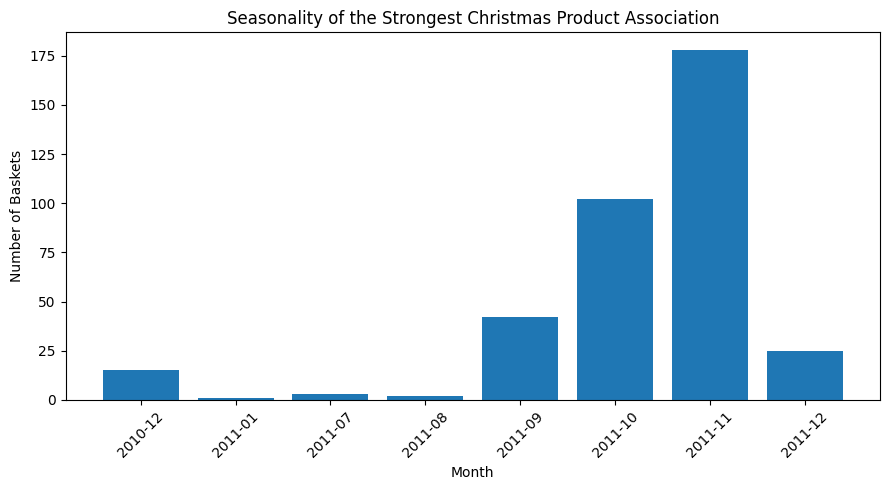

In [29]:
# Visualise seasonality of the strongest Christmas association
seasonality_plot = monthly_pair_counts.copy()

plt.figure(figsize=(9, 5))

plt.bar(
    seasonality_plot.index.astype(str),
    seasonality_plot.values
)

plt.title(
    "Seasonality of the Strongest Christmas Product Association"
)
plt.xlabel("Month")
plt.ylabel("Number of Baskets")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Limitations

This analysis has several important limitations.

First, association rules identify co-occurrence patterns rather than causal relationships. A strong rule does not imply that purchasing one product causes the purchase of another.

Second, the analysis focuses on UK transactions because they represent the large majority of the dataset. Purchasing behaviour in other markets may differ.

Third, a minimum support threshold of 2% prioritises recurring and commercially relevant patterns but may exclude meaningful associations involving less frequently purchased products.

The analysis also treats product presence as binary and does not incorporate the quantity purchased within each basket.

Finally, some associations are strongly influenced by seasonality. The Christmas Scandinavian product pair, for example, shows that high lift may reflect a concentrated seasonal purchasing pattern rather than a stable year-round relationship.

Association rules should therefore be interpreted alongside transaction volume, business context, product seasonality and commercial objectives before being used for recommendations or promotions.

## Next Steps

Several extensions could strengthen the analysis further.

- Evaluate association rules across different time periods to measure seasonal stability.
- Compare UK purchasing patterns with other countries represented in the dataset.
- Explore lower support thresholds for niche or long-tail product relationships.
- Incorporate product quantity and revenue to distinguish frequent associations from commercially valuable ones.
- Test recommendation strategies based on high-confidence and high-lift rules.
- Measure whether proposed bundles or cross-selling recommendations improve conversion or basket value in a real retail environment.

A production recommendation system would ideally combine association rules with behavioural, temporal and commercial information rather than relying on transaction co-occurrence alone.

## Conclusion

This project used association rule mining to identify meaningful product relationships within UK online retail transactions.

After cleaning the transactional data and removing non-merchandise invoice lines, 17,901 baskets containing 3,902 products were analysed.

Apriori was applied using a minimum support threshold of 2%, producing 412 frequent itemsets and 242 association rules. A confidence threshold of 40% was used to focus the analysis on stronger relationships.

The results revealed several commercially meaningful patterns, particularly within coordinated product families such as Regency tableware, Jumbo Bags, Lunch Bags and seasonal Christmas products.

The analysis also demonstrated why association strength and commercial relevance should not be evaluated using a single metric. Lift highlights unusually strong relationships, while support and basket volume indicate how widely those relationships occur across real transactions.

Several rules provide clear opportunities for cross-selling, product bundling and recommendation strategies. However, the seasonality analysis also showed that strong aggregate associations may be highly time-dependent.

Overall, Market Basket Analysis provides a useful way to translate transactional purchasing behaviour into actionable retail insights, provided that association rules are interpreted alongside business context, volume, seasonality and operational objectives.